In [1]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import sys
sys.path.append("/Users/tdinelli/Documents/GitHub/diffPLOG2TROE")
from diffPLOG2TROE.rate_constants import FallOff, Plog, Arrhenius
from diffPLOG2TROE.plog_refitter import PlogRefitter
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.lines import Line2D

In [19]:
plog_dict = {
    "name": "NH2+H=NH3",
    "type": "plog",
    "rate-constant": {
        "coefficients": [
            [1.00000e-01, 1.21300e+27, -4.95900e+00, 2.80709e+03],
            [1.00000e+00, 5.86700e+27, -4.86700e+00, 3.10796e+03],
            [1.00000e+01, 3.31400e+28, -4.79800e+00, 3.83238e+03],
            [1.00000e+02, 4.51200e+28, -4.56300e+00, 4.72319e+03]
        ]
    }
}
param_config = {
    "A_high": {"optimize": False, "value": 1.50e+14},
    "n_high": {"optimize": False, "value": 0.167},
    "E_high": {"optimize": False, "value": 0.0},
}

plog_dict = {
    "name": "HNO2=HONO",
    "type": "plog",
    "rate-constant": {
        "coefficients": [
            [0.01, 3.260000e+34, -7.97, 45490.0],
            [0.1,  2.770000e+33, -7.58, 45250.0],
            [0.316, 1.930000e+32, -7.18, 44940.0],
            [1.0,  1.560000e+30, -6.47, 44360.0],
            [3.16, 2.170000e+27, -5.49, 43670.0],
            [10.0, 4.680000e+24, -4.52, 43320.0],
            [31.6, 1.140000e+23, -3.81, 43640.0],
            [100.0, 2.030000e+22, -3.35, 44430.0]
        ]
    }
}
param_config = {
    "A_high": {"optimize": False, "value": 0.},
    "n_high": {"optimize": False, "value": 0.},
    "Ea_high": {"optimize": False, "value": 0.},
    "A_high": {"optimize": False, "value": 0.},
    "n_high": {"optimize": False, "value": 0.},
    "Ea_high": {"optimize": False, "value": 0.},
}

plog_dict = {
    "name": "OH+NO(+M)=OHNO(+M)",
    "type": "plog",
    "rate-constant": {
        "coefficients": [
            [0.01, 5.020000e+21, -4.24, 898.9],
            [0.1,  5.310000e+22, -4.24, 1184.0],
            [0.316,1.380000e+23, -4.22, 1376.0],
            [1.0,  3.090000e+23, -4.17, 1621.0],
            [3.16, 5.450000e+23, -4.09, 1911.0],
            [10.0, 6.350000e+23, -3.97, 2222.0],
            [31.6, 3.680000e+23, -3.75, 2501.0],
            [100.0,7.290000e+22, -3.41, 2660.0]
        ]
    }
}

plog_dict = {
    "name": "H+NO(+M)=H2NO(+M)",
    "type": "plog",
    "rate-constant": {
        "coefficients": [
            [0.01  ,.5670E+24,  -4.590, 5690.0],
            [0.10  ,.5690E+26,  -4.800, 4233.0],
            [1.00  ,.2680E+28,  -4.940, 4849.0],
            [10.0  ,.2550E+28,  -4.630, 5539.0],
            [100.0 ,.4840E+26,  -3.870, 5867.0],
        ]
    }
}

refitter = PlogRefitter(
    plog_dict,
    T_range=(600, 2500),
    P_range=(0.01, 100),
    n_T=100,
    n_P=100,
    # loss_name="log-squared-error",
    loss_name="log-logcosh",
    log_name="optaxlbfgs.log",
    falloff_type="troe"
)

optax_options = {
    "algorithm": "adam",
    "patience": 300,
    "max_steps": 10000,
    "steps_file": 100,
    "ftol": 1e-8,
    "line_search": "backtracking"
}

nlopt_options = {
    "algorithm": "ESCH",
    "max_eval": 700000,
    "ftol_rel": 1e-10,
    "xtol_rel": 1e-10,
    "steps_file": 7000,
    "patience": 1000,
}

initial_troe = refitter.fit(optax_options=optax_options)
# initial_troe = refitter.fit(nlopt_options=nlopt_options)

print(FallOff(initial_troe))

Plog 2 TROE refitter
 Temperature range [K]: (600, 2500)
 Pressure range [atm]: (0.01, 100)
 Loss function: log-logcosh

Parameters configuration:
  A_low: optimizing from default initial value
  n_low: optimizing from default initial value
  E_low: optimizing from default initial value
  A_high: optimizing from default initial value
  n_high: optimizing from default initial value
  E_high: optimizing from default initial value
  A: optimizing from default initial value
  T3: optimizing from default initial value
  T1: optimizing from default initial value
  T2: optimizing from default initial value

Starting optimization
First guess estimate of the parameters:
  Troe parameters (A, T3, T1, T2): 0.500, 1.085e+03, 3.100e+02, 2.325e+03

  High pressure limit (A, n, Ea): 4.840e+25, -3.870, 5.867e+03
  Low pressure limit (A, n, Ea): 4.653e+27, -3.590, 5.690e+03
Starting optimization with adam algorithm
  Step 0: loss = 9.826039e-01, grad_norm = 5.449592e+00
  Step 100: loss = 3.796968e-01,

H+NO(+M)=H2NO(+M)		1.46401e+25 -3.41627 5.87548e+03
 LOW / 		1.50002e+29 -3.87804 5.67544e+03 /
 TROE / 0.00000e+00 1.09219e+03 3.10336e+02 2.31928e+03 /


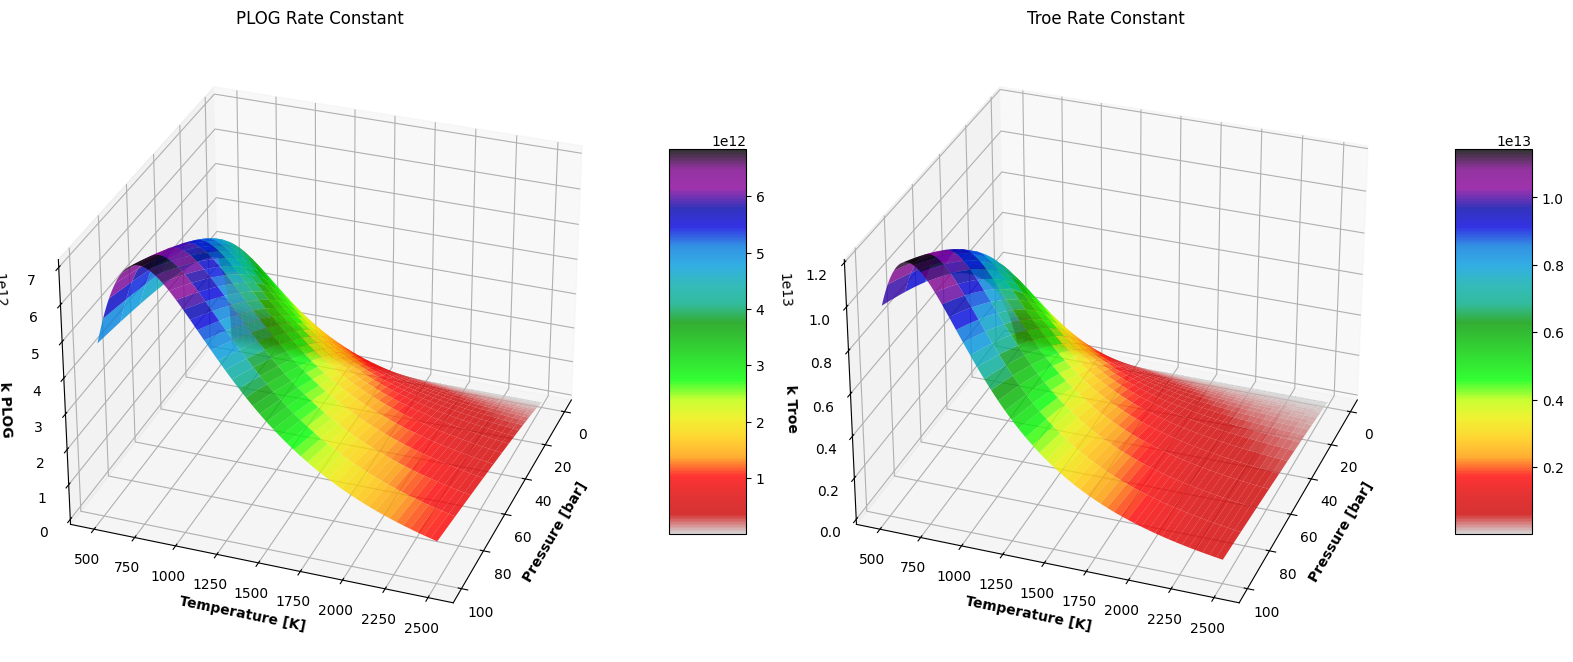

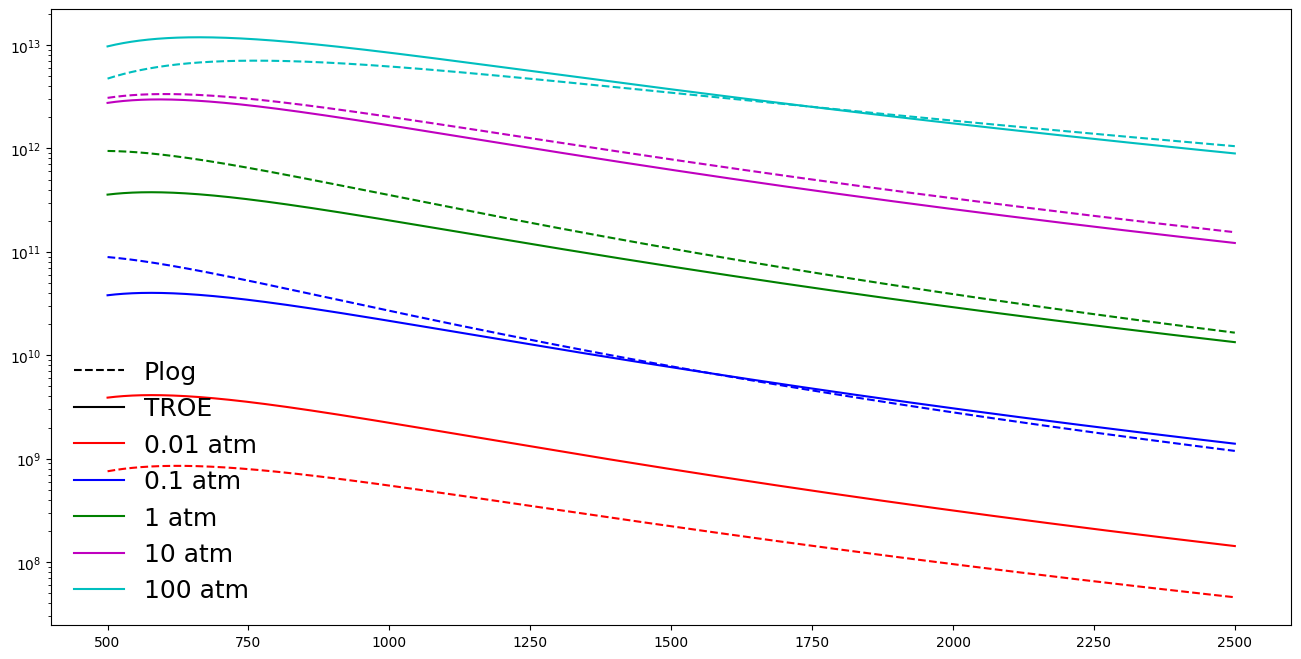

In [20]:
plog = Plog(plog_dict)
troe = FallOff(initial_troe)

T_range = jnp.linspace(500, 2500, 1000)
P_range = jnp.logspace(jnp.log10(0.01), jnp.log10(100), 1000)
T_mesh, P_mesh = jnp.meshgrid(T_range, P_range)

k_plog = plog.kinetic_constant(T_range, P_range)
k_troe = troe.kinetic_constant(T_range, P_range)

# Create figure and 3D subplots
fig = plt.figure(figsize=(16, 8))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

# Create surface plots
surf1 = ax1.plot_surface(
    P_mesh, T_mesh, k_plog,
    cmap='nipy_spectral_r',
    linewidth=0,
    antialiased=True,
    alpha=0.8
)

surf2 = ax2.plot_surface(
    P_mesh, T_mesh, k_troe,
    cmap='nipy_spectral_r',
    linewidth=0,
    antialiased=True,
    alpha=0.8
)

# Set labels and titles
ax1.set_xlabel('Pressure [bar]', fontweight='bold')
ax1.set_ylabel('Temperature [K]', fontweight='bold')
ax1.set_zlabel('k PLOG', fontweight='bold')
ax1.set_title('PLOG Rate Constant')

ax2.set_xlabel('Pressure [bar]', fontweight='bold')
ax2.set_ylabel('Temperature [K]', fontweight='bold')
ax2.set_zlabel('k Troe', fontweight='bold')
ax2.set_title('Troe Rate Constant')

# Add colorbars
cbar1 = fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=5)
cbar2 = fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=5)

ax1.view_init(azim=20)
ax2.view_init(azim=20)

plt.tight_layout()
plt.show()

P_levels = jnp.array([0.01, 0.1, 1, 10, 100])
# P_levels = jnp.array([0.1, 1, 10, 100])
k_plog = plog.kinetic_constant(T_range, P_levels)
k_troe = troe.kinetic_constant(T_range, P_levels)

fig, ax = plt.subplots(figsize=(16, 8))
colors = ["r", "b", "g", "m", "c"]
for i, (ki_plog, ki_troe) in enumerate(zip(k_plog, k_troe)):
    ax.plot(T_range, ki_plog, '--', color=colors[i])
    ax.plot(T_range, ki_troe, '-', color=colors[i])


custom_lines = [
    Line2D([0], [0], color="k", linestyle="--", lw=1.5),
    Line2D([0], [0], color="k", linestyle="-", lw=1.5),
    Line2D([0], [0], color=colors[0], linestyle="-", lw=1.5),
    Line2D([0], [0], color=colors[1], linestyle="-", lw=1.5),
    Line2D([0], [0], color=colors[2], linestyle="-", lw=1.5),
    Line2D([0], [0], color=colors[3], linestyle="-", lw=1.5),
    Line2D([0], [0], color=colors[4], linestyle="-", lw=1.5),
]
ax.legend(
    custom_lines,
    ["Plog", "TROE", "0.01 atm", "0.1 atm", "1 atm", "10 atm", "100 atm",],
    frameon=False,
    fontsize=18,
)

ax.set_yscale("log")

Minimum error: 0.5206038162806234
Maximum error: 1.1840304772427952
Average error: 0.18082615746677055


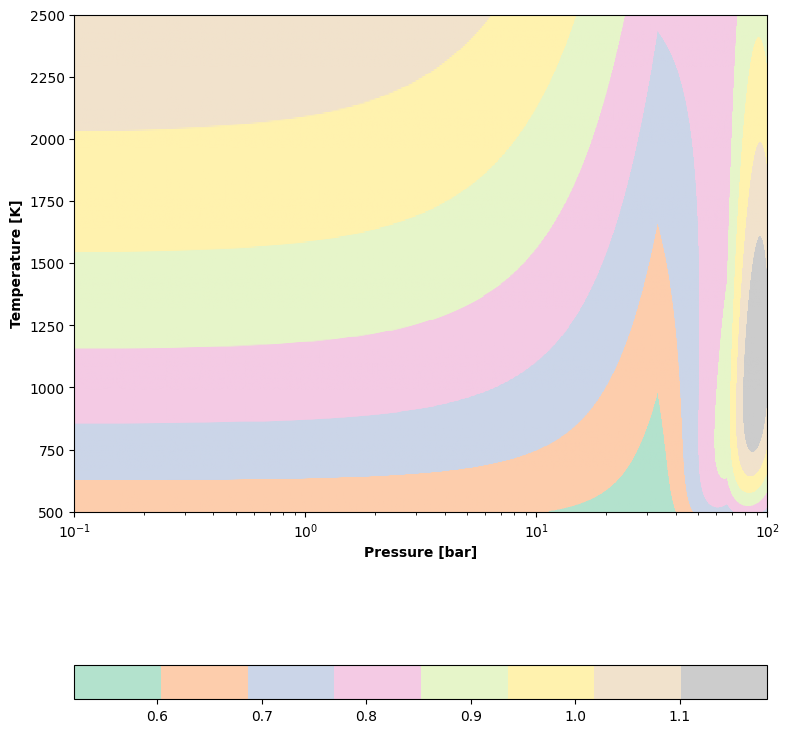

In [15]:
T_range = jnp.linspace(500, 2500, 1000)
P_range = jnp.logspace(jnp.log10(0.1), jnp.log10(100), 1000)
T_mesh, P_mesh = jnp.meshgrid(T_range, P_range)
k_plog = plog.kinetic_constant(T_range, P_range)
k_troe = troe.kinetic_constant(T_range, P_range)
ratio = k_troe.T / k_plog.T
rel_ratio = jnp.mean(jnp.sqrt((1 - k_troe.T / k_plog.T) ** 2))

plt.figure(figsize=(8, 8))
im = plt.imshow(
    ratio,
    origin="lower",
    aspect="auto",
    extent=[P_range[0], P_range[-1], T_range[0], T_range[-1]],
    cmap="Pastel2"
)
    
plt.xscale("log")
plt.xlabel("Pressure [bar]", fontweight="bold")
plt.ylabel("Temperature [K]", fontweight="bold")    
cbar = plt.colorbar(im, orientation="horizontal", pad=0.2)

print(f"Minimum error: {jnp.min(ratio)}")
print(f"Maximum error: {jnp.max(ratio)}")
print(f"Average error: {rel_ratio}")

plt.tight_layout()
plt.show()